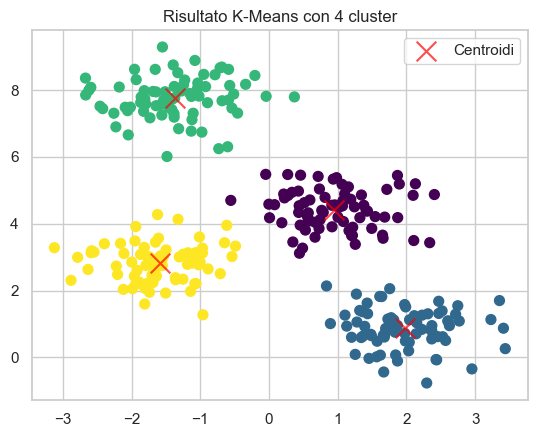

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# Impostiamo lo stile estetico
sns.set_theme(style="whitegrid")

# 1 Generazione dati (4 gruppi distinti)
X,y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Inizializzazione e Addestramento del modello
# n_init=10 indica quante volte l'algoritmo riparte con centroidi diversi
kmeans = KMeans(n_clusters=4, n_init=10,random_state=0)
kmeans.fit(X)

# 3. Predizione dei cluster
y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_

# 4. Visualizzazione
plt.scatter(X[:,0], X[:,1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', alpha=0.7, marker='x',label='Centroidi')
plt.title("Risultato K-Means con 4 cluster")
plt.legend()
plt.show()

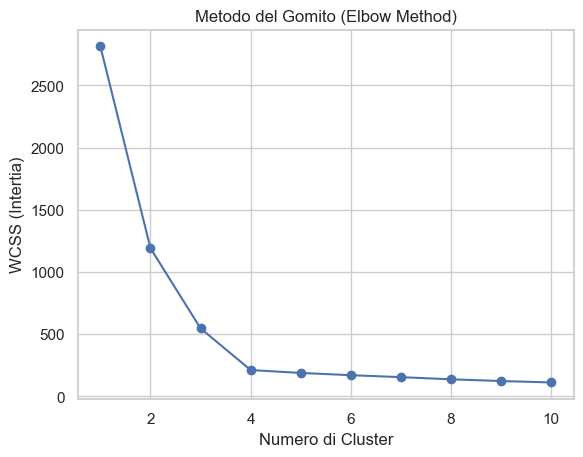

In [8]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, n_init=10, random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Metodo del Gomito (Elbow Method)')
plt.xlabel('Numero di Cluster')
plt.ylabel('WCSS (Intertia)')
plt.show()

In [9]:
score = silhouette_score(X, y_kmeans)
print(f"Silhouette score per k=4: {score:.3f}")

Silhouette score per k=4: 0.682
